In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Input

In [2]:
# =========================
# 2. LOAD DATASET
# =========================
df = pd.read_csv("Google_Stock_Price.csv", thousands=',')

# Clean and extract 'Open' column
data = pd.to_numeric(df['Open'], errors='coerce').dropna().values.reshape(-1, 1)

In [5]:
# =========================
# 3. TRAIN-TEST SPLIT
# =========================
train_size = int(len(data) * 0.8)

train_data = data[:train_size]
test_data = data[train_size:]


In [7]:
# =========================
# 4. FEATURE SCALING
# =========================
scaler = MinMaxScaler(feature_range=(0,1))

train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

In [9]:
# =========================
# 5. CREATE TIME SERIES DATA
# =========================
def create_dataset(dataset):
    X, y = [], []
    for i in range(60, len(dataset)):
        X.append(dataset[i-60:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_data)
X_test, y_test = create_dataset(test_data)

# Reshape for RNN [samples, timesteps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [11]:
# =========================
# 6. BUILD RNN MODEL
# =========================
model = Sequential()

model.add(Input(shape=(60,1)))
model.add(SimpleRNN(50, return_sequences=True))
model.add(SimpleRNN(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# =========================
# 7. TRAIN MODEL
# =========================
history = model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.0204
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0030
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0022
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0019
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0014
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0013
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0011
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 9.3228e-04
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 9.0100e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 8.4189e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 8.5022e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 7.6568e-04
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 6.9779e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 8.6341e-04
Epoch 15/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [15]:
# =========================
# 8. PREDICTION
# =========================
predicted = model.predict(X_test)

# Inverse scaling
predicted = scaler.inverse_transform(predicted)
real = scaler.inverse_transform(y_test.reshape(-1,1))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


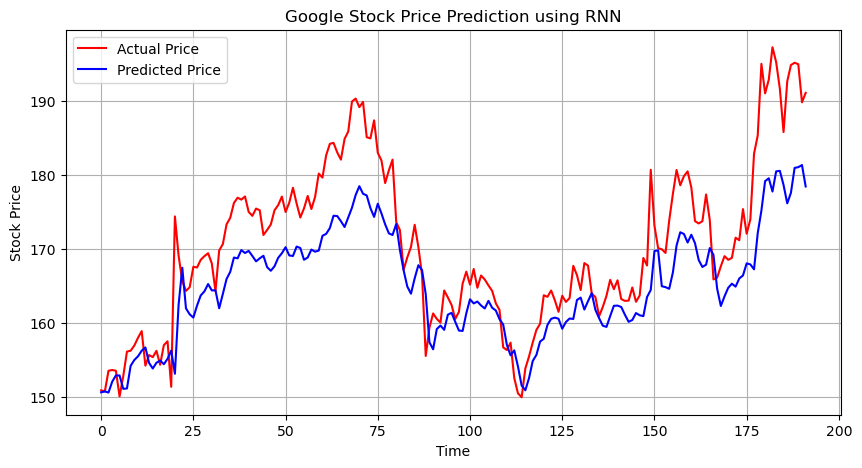

In [17]:
# =========================
# 9. VISUALIZATION
# =========================
plt.figure(figsize=(10,5))

plt.plot(real, color='red', label='Actual Price')
plt.plot(predicted, color='blue', label='Predicted Price')

plt.title("Google Stock Price Prediction using RNN")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.grid()

plt.show()